In [1]:
import ast
import numpy as np
import pandas as pd

from common import FEATURES_OUTFILE
from dmm.config_options import Conf
from dmm.feature_selection import load_data, build_preprocessor
from dmm.initialisation import get_features
from regressor_training import *
from sklearn.impute import KNNImputer
from sklearn.model_selection import PredefinedSplit
from util import load_petab_base_files
from tqdm import tqdm

In [2]:
# Helper function to filter columns
def filter_relevant_columns(df):
    return [col for col in df.columns if col[0] in {"pERK_Y204_obs", "pMEK_S222_obs", "pERBB2_Y1248_obs"}]

# Modified RMSE computation function
def masked_rmse(true_df, pred_df):
    # print("Fraction of NaN values in true_df: ", np.isnan(true_df).sum().sum() / true_df.size)
    squared_errors = (true_df - pred_df) ** 2
    rmse = np.sqrt(np.nanmean(squared_errors.values))
    return rmse

In [3]:
include_perbb2_forced = False
context = "cytof_init"

In [4]:
# Use only a single sample split
samples = "0of5"
rmses = {}

# Set up config
conf_dict = {
    "model": "EGFR_MAPK",
    "data": "dream_cytof",
    "samples": samples,
    "features": "all",
    "context": "cytof_dynamic",
}

# Load both train and val data for 0of5
features_filepath = FEATURES_OUTFILE.format(
    **{**conf_dict, **dict(dataset="{dataset}")}
)
settings = {
    "train": ["train"],
    "test": ["val"],
    "train+test": ["train", "val"],
}

temp_features_samples = get_features(
    features_filepath=features_filepath,
    datasets=settings["train+test"]
)
for key in temp_features_samples.keys():
    temp_features_samples[key].columns = [ast.literal_eval(col) if isinstance(col, str) and col.startswith('(') else col for col in temp_features_samples[key].columns]

# Concatenate train and val
all_features = pd.concat(temp_features_samples.values())
cell_lines = all_features.index.unique()

# Use cell_lines from above to get the list of all samples
cell_line_list = cell_lines.tolist()

loo_splits = {
    cell_line: {
        "train": [cl for cl in cell_line_list if cl != cell_line],
        "val": [cell_line],
    }
    for cell_line in cell_line_list
}

Get all features for all possible CV splits (one per cell-line)

In [5]:
conf = Conf(
    model="EGFR_MAPK",
    data="dream_cytof",
    context=context,
    features="elastic",
)
petab_base_files = load_petab_base_files(conf)
del petab_base_files["condition_table"]

input_parts = []
output_parts = []
features_all = None
all_indices = []
split_indices = []


for val_cell_line in (pbar := tqdm(loo_splits.keys())):
    pbar.set_description(f"Processing {val_cell_line}")
    training_samples = loo_splits[val_cell_line]["train"]
    val_samples = loo_splits[val_cell_line]["val"]

    input_train, features_all = load_data(
        contextualization=conf.context,
        samples=training_samples,
        features=None,
        **petab_base_files,
    )
    input_val, _ = load_data(
        contextualization=conf.context,
        samples=val_samples,
        features=features_all,
        **petab_base_files,
    )

    output_train, features_output_train = load_data(
        contextualization="cytof_dynamic",
        samples=training_samples,
        features=None,
        **petab_base_files,
    )
    output_val, _ = load_data(
        contextualization="cytof_dynamic",
        samples=val_samples,
        features=features_output_train,
        **petab_base_files,
    )

    imputer = KNNImputer()
    imputer.fit(output_train)

    output_train_filled = pd.DataFrame(
        imputer.transform(output_train),
        index=output_train.index,
        columns=output_train.columns,
    )
    output_val_filled = pd.DataFrame(
        imputer.transform(output_val),
        index=output_val.index,
        columns=output_val.columns,
    )

    # Concatenate and record indices for PredefinedSplit
    n_before = len(all_indices)
    input_parts.extend([input_train, input_val])
    output_parts.extend([output_train_filled, output_val_filled])
    all_indices.extend(input_train.index.tolist() + input_val.index.tolist())

    train_idx = list(range(n_before, n_before + len(input_train)))
    val_idx = list(range(n_before + len(input_train), n_before + len(input_train) + len(input_val)))
    split_indices.append((train_idx, val_idx))

# Combine everything
input_all = pd.concat(input_parts)
output_all = pd.concat(output_parts)

assert input_all.shape[0] == output_all.shape[0], "Mismatched rows between inputs and outputs"
assert all(input_all.index == output_all.index), "Mismatched indices between inputs and outputs"

Processing cMCF7: 100%|██████████| 52/52 [00:43<00:00,  1.20it/s]       


Perform feature selection on the entire set of LOO-CV splits

In [6]:
# Create PredefinedSplit for feature selection
test_fold = [-1] * len(input_all)

for split_idx, (_, val_idx) in enumerate(split_indices):
    for i in val_idx:
        test_fold[i] = split_idx

cv = PredefinedSplit(test_fold)

# Build and fit global preprocessor
preprocessor = build_preprocessor(conf.features, input_all, output_all, cv=cv)
preprocessor = preprocessor.fit(input_all, output_all)

if conf.features == "all":
    selected_features = features_all
else:
    selector = preprocessor.steps[-1][1]
    selected_features = preprocessor.feature_names_in_[selector.get_support()]

print(f"Selected {len(selected_features)} features shared across splits for {conf.context}: {selected_features}")

Selected 14 features shared across splits for cytof_init: ['CyclinB' 'GAPDH' 'p.Akt.Ser473.' 'p.FAK' 'p.GSK3b' 'p.MKK3.MKK6'
 'p.NFkB' 'p.PLCg2' 'p.S6K' 'p.STAT5' 'p.p38' 'p.p90RSK' 'pERK_Y204_obs'
 'pMEK_S222_obs']


Optionally force the inclusion of pERBB2_Y1248_obs

In [7]:
if (include_perbb2_forced) and (context == "cytof_init") and ("pERBB2_Y1248_obs" not in selected_features):
    print("pERBB2_Y1248_obs not in selected features, adding it")
    selected_features = np.append(selected_features, "pERBB2_Y1248_obs")

Train pipelines and get RMSE scores

In [8]:
# Transform and save per split
selected_inputs = {}
selected_outputs = {}
selected_unimputed_outputs = {}
rmses = {}

for val_cell_line in (pbar := tqdm(loo_splits.keys())):
    pbar.set_description(f"Processing {val_cell_line}")
    selected_inputs[val_cell_line] = {}
    selected_outputs[val_cell_line] = {}
    selected_unimputed_outputs[val_cell_line] = {}
    rmses[val_cell_line] = {}

    input_train, _ = load_data(
        contextualization=conf.context,
        samples=loo_splits[val_cell_line]["train"],
        features=features_all,
        **petab_base_files,
    )
    input_val, _ = load_data(
        contextualization=conf.context,
        samples=loo_splits[val_cell_line]["val"],
        features=features_all,
        **petab_base_files,
    )

    output_train, features_output_train = load_data(
        contextualization="cytof_dynamic",
        samples=loo_splits[val_cell_line]["train"],
        features=None,
        **petab_base_files,
    )
    output_val, _ = load_data(
        contextualization="cytof_dynamic",
        samples=loo_splits[val_cell_line]["val"],
        features=features_output_train,
        **petab_base_files,
    )

    imputer = KNNImputer()
    imputer.fit(output_train)

    output_train_filled = pd.DataFrame(
        imputer.transform(output_train),
        index=output_train.index,
        columns=output_train.columns,
    )
    output_val_filled = pd.DataFrame(
        imputer.transform(output_val),
        index=output_val.index,
        columns=output_val.columns,
    )

    for dataset, inputs, outputs, unimputed_outputs in zip(
            ("train", "val"),
            (input_train, input_val),
            (output_train_filled, output_val_filled),
            (output_train, output_val)
    ):
        selected_inputs[val_cell_line][dataset] = pd.DataFrame(
            inputs[selected_features].values,
            index=inputs.index,
            columns=selected_features
        )
        selected_outputs[val_cell_line][dataset] = outputs
        selected_unimputed_outputs[val_cell_line][dataset] = unimputed_outputs

    for regressor_mode in ["linreg", "lasso", "elasticnet"]:
        rmses[val_cell_line][regressor_mode] = {}
        trained_pipeline, features_train = train_pipeline(
            input_data_train=selected_inputs[val_cell_line]["train"],
            output_data_train=selected_outputs[val_cell_line]["train"],
            pipeline_steps=[regressor_mode],
        )
        train_pred = trained_pipeline.predict(selected_inputs[val_cell_line]["train"])
        train_pred = pd.DataFrame(
            train_pred,
            index=selected_inputs[val_cell_line]["train"].index,
            columns=selected_outputs[val_cell_line]["train"].columns
        )
        val_pred = trained_pipeline.predict(selected_inputs[val_cell_line]["val"])
        val_pred = pd.DataFrame(
            val_pred,
            index=selected_inputs[val_cell_line]["val"].index,
            columns=selected_outputs[val_cell_line]["val"].columns
        )

        # Get the columns that match pERK, pMEK, pERBB2
        relevant_cols_train = filter_relevant_columns(selected_outputs[val_cell_line]["train"])
        relevant_cols_val = filter_relevant_columns(selected_outputs[val_cell_line]["val"])

        # compute masked rmse
        rmses[val_cell_line][regressor_mode]["train"] = masked_rmse(
            selected_unimputed_outputs[val_cell_line]["train"][relevant_cols_train],
            train_pred[relevant_cols_train],
        )
        rmses[val_cell_line][regressor_mode]["val"] = masked_rmse(
            selected_unimputed_outputs[val_cell_line]["val"][relevant_cols_val],
            val_pred[relevant_cols_val],
        )

Processing cMCF7: 100%|██████████| 52/52 [00:56<00:00,  1.09s/it]       


Convert RMSEs to DataFrame and save in CSV format

In [9]:
# Convert rmses to a DataFrame (long format)
rmses_list = []

for cell_line, regressors in rmses.items():
    for regressor, splits in regressors.items():
        for split, rmse_value in splits.items():
            rmses_list.append({
                "val_cell_line": cell_line,
                "regressor": regressor,
                "split": split,  # 'train' or 'val'
                "rmse": rmse_value
            })

regressors_rmses_df = pd.DataFrame(rmses_list)
regressors_rmses_df.to_csv(f"{context}_regressors_rmses_df_loocv_forcedERBB2_{include_perbb2_forced}.csv", index=False)

Barplot (per regressor)

/Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/fabring/dmm_env_310/lib/pyt

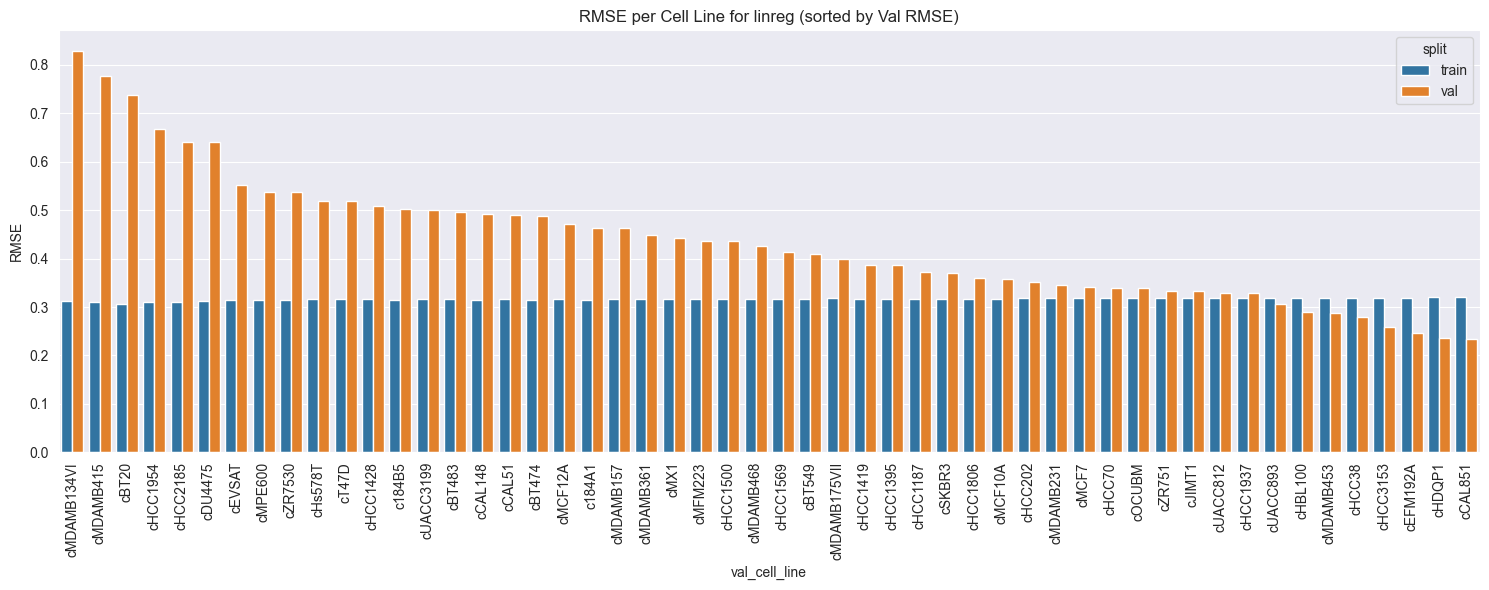

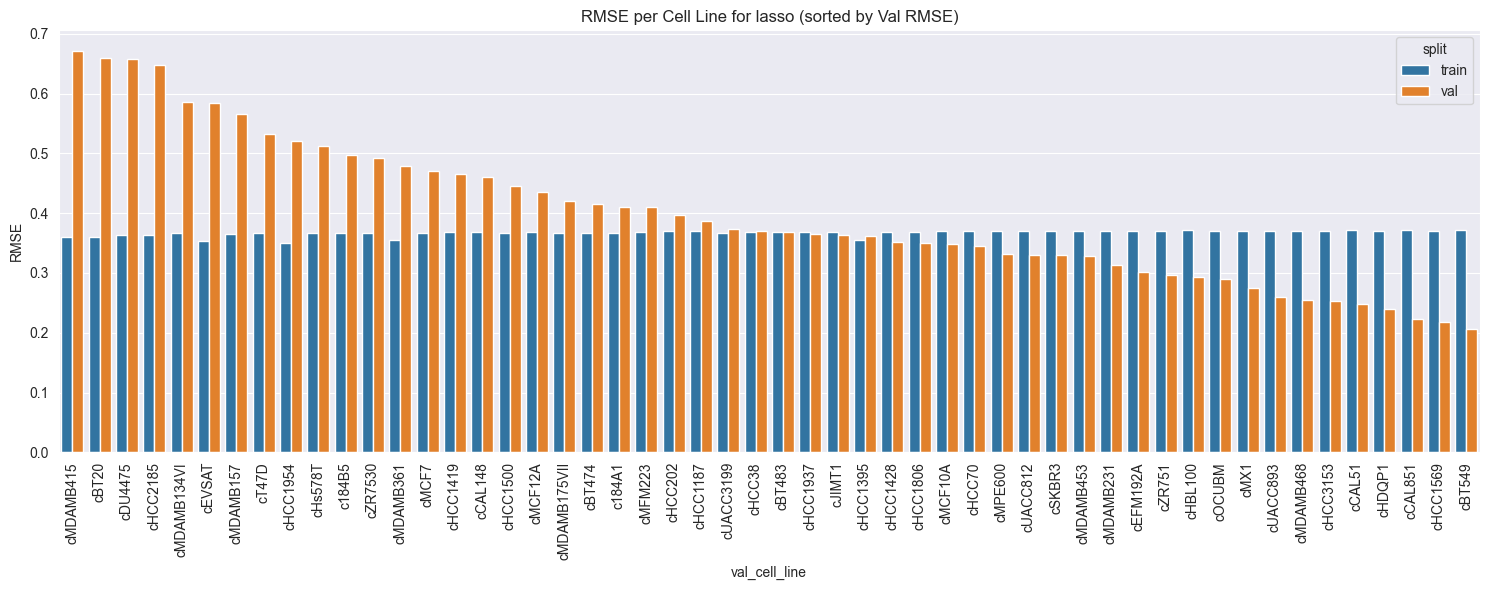

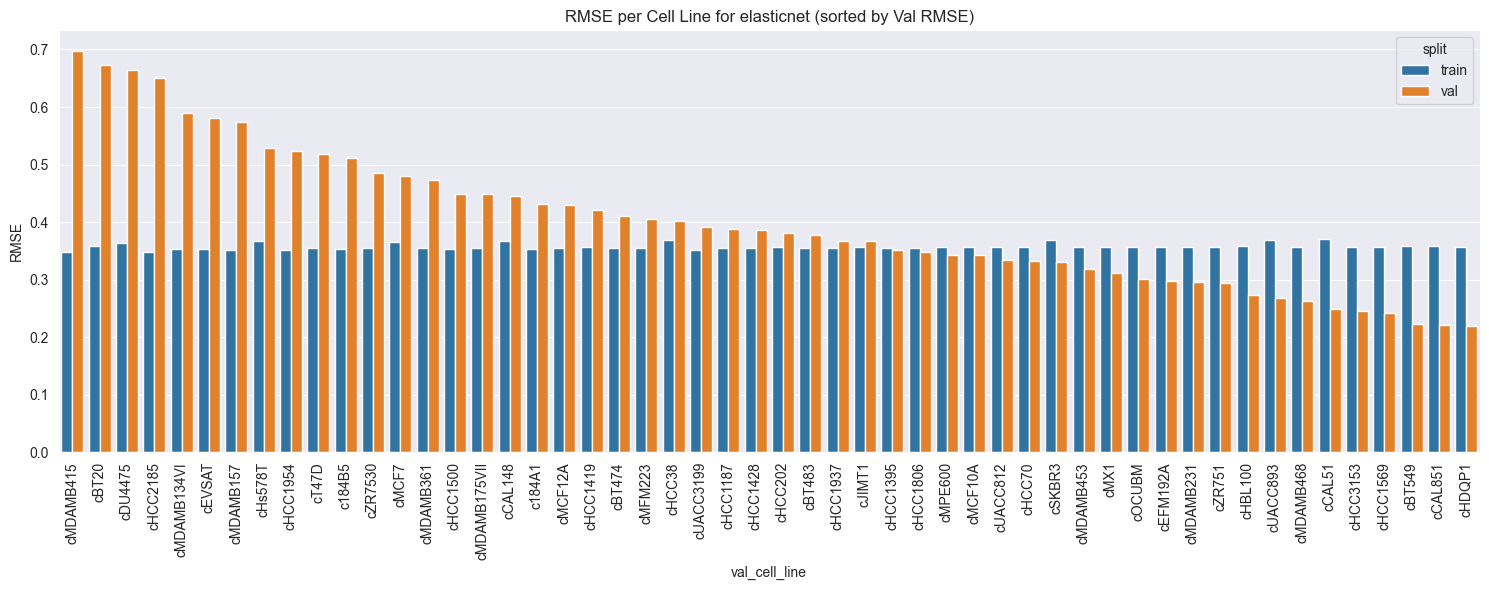

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loop over each regressor separately
for regressor in regressors_rmses_df["regressor"].unique():

    # Filter to this regressor
    regressor_df = regressors_rmses_df[regressors_rmses_df["regressor"] == regressor]

    # Sort by validation RMSE (descending)
    val_sorted = regressor_df[regressor_df["split"] == "val"]
    val_sorted = val_sorted.sort_values("rmse", ascending=False)

    # Set the correct order for x-axis
    order = val_sorted["val_cell_line"].tolist()

    # 2. Plot for this regressor
    plt.figure(figsize=(15, 6))
    sns.barplot(
        data=regressor_df,
        x="val_cell_line",
        y="rmse",
        hue="split",
        order=order,  # <-- apply correct order
    )
    plt.xticks(rotation=90)
    plt.ylabel("RMSE")
    plt.title(f"RMSE per Cell Line for {regressor} (sorted by Val RMSE)")
    plt.tight_layout()
    plt.savefig(f"{context}_hardest_cell_lines_{regressor}.png")

Find the top 5 hardest cell-lines (consensus among the 3 regressor types)

In [11]:
# Find the top 5 highest validation RMSEs per regressor
top5_per_regressor = {}

for regressor in regressors_rmses_df["regressor"].unique():
    regressor_df = regressors_rmses_df[
        (regressors_rmses_df["regressor"] == regressor) &
        (regressors_rmses_df["split"] == "val")
    ]
    # Sort descending and take top 5
    top5 = regressor_df.sort_values("rmse", ascending=False).head(5)["val_cell_line"].tolist()
    top5_per_regressor[regressor] = top5

# Now find consensus across regressors
from collections import Counter

# Flatten all top 5 into one list
all_top5 = sum(top5_per_regressor.values(), [])

# Count appearances
top5_counts = Counter(all_top5)

# Optional: display counts
print("Top5 counts across regressors:")
for cell_line, count in top5_counts.most_common():
    print(f"{cell_line}: {count} times")

# Find cell-lines appearing in top 5 for most regressors
# For example, those appearing at least 2 times
consensus_top5 = [cell_line for cell_line, count in top5_counts.items() if count >= 2]

print("\nConsensus Top Cell Lines:")
print(consensus_top5)

Top5 counts across regressors:
cMDAMB134VI: 3 times
cMDAMB415: 3 times
cBT20: 3 times
cHCC2185: 3 times
cDU4475: 2 times
cHCC1954: 1 times

Consensus Top Cell Lines:
['cMDAMB134VI', 'cMDAMB415', 'cBT20', 'cHCC2185', 'cDU4475']


Get mean and std of RMSE for consensus top5 cell lines

In [12]:
# 1. Filter the dataframe to validation split only
val_df = regressors_rmses_df[regressors_rmses_df["split"] == "val"]

# 2. Further filter to only the consensus top5 cell lines
consensus_val_df = val_df[val_df["val_cell_line"].isin(consensus_top5)]

# 3. Group by cell line and calculate mean and standard deviation
consensus_stats = consensus_val_df.groupby("val_cell_line")["rmse"].agg(["mean", "std"]).reset_index()

# 4. Display nicely
print("Mean and Standard Deviation of Validation RMSE for Consensus Top Cell Lines:")
print(consensus_stats)

Mean and Standard Deviation of Validation RMSE for Consensus Top Cell Lines:
  val_cell_line      mean       std
0         cBT20  0.690064  0.041409
1       cDU4475  0.654077  0.012713
2      cHCC2185  0.646407  0.004510
3   cMDAMB134VI  0.668244  0.139825
4     cMDAMB415  0.715664  0.054372


Find the regressor type with best average validation RMSE across consensus hardest cell lines

In [13]:
# 1. Already have val_df: validation-only RMSEs
val_df = regressors_rmses_df[regressors_rmses_df["split"] == "val"]

# 2. Filter to only consensus top cell lines
consensus_val_df = val_df[val_df["val_cell_line"].isin(consensus_top5)]

# 3. Group by regressor and compute mean RMSE across these consensus lines
regressor_performance = consensus_val_df.groupby("regressor")["rmse"].mean().reset_index()

# 4. Sort ascending (lower RMSE is better)
regressor_performance = regressor_performance.sort_values("rmse", ascending=True)

# 5. Display
print("Average Validation RMSE across Consensus Top Cell Lines (per Regressor):")
print(regressor_performance)

Average Validation RMSE across Consensus Top Cell Lines (per Regressor):
    regressor      rmse
1       lasso  0.644345
0  elasticnet  0.655336
2      linreg  0.724992


Find best regressor modality for current CV split

In [14]:
# 1. Already have val_df: validation-only RMSEs
val_df = regressors_rmses_df[regressors_rmses_df["split"] == "val"]

# 2. Filter to only consensus top cell lines
consensus_val_df = val_df[val_df["val_cell_line"].isin(["cMCF7", "cBT20", "cHCC1500", "cEVSAT", "cHCC2185"])]

# 3. Group by regressor and compute mean RMSE across these consensus lines
regressor_performance = consensus_val_df.groupby("regressor")["rmse"].mean().reset_index()

# 4. Sort ascending (lower RMSE is better)
regressor_performance = regressor_performance.sort_values("rmse", ascending=True)

# 5. Display
print("Average Validation RMSE across Consensus Top Cell Lines (per Regressor):")
print(regressor_performance)

Average Validation RMSE across Consensus Top Cell Lines (per Regressor):
    regressor      rmse
2      linreg  0.541791
1       lasso  0.561270
0  elasticnet  0.566691


In [15]:
# Examine the current performance of regressors on current CV cell lines
regressors_rmses_df[
    (regressors_rmses_df.val_cell_line.isin(["cMCF7", "cBT20", "cHCC1500", "cEVSAT", "cHCC2185"]))
].sort_values(["val_cell_line", "regressor", "split"], ascending=True)

,val_cell_line,regressor,split,rmse
16,cBT20,elasticnet,train,0.358152
17,cBT20,elasticnet,val,0.673637
14,cBT20,lasso,train,0.359672
15,cBT20,lasso,val,0.659390
12,cBT20,linreg,train,0.306796
13,cBT20,linreg,val,0.737167
70,cEVSAT,elasticnet,train,0.352905
71,cEVSAT,elasticnet,val,0.581593
68,cEVSAT,lasso,train,0.352792
69,cEVSAT,lasso,val,0.583772
